In [31]:
#System stuff
import os
import sys
import time
from pathlib import Path
from datetime import datetime

# Base Jupyter libraries
import pandas as pd
import numpy as np
import random

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

#image handling
import tifffile as tiff
from skimage.transform import resize
from scipy import ndimage

#Keras and Tensorflow
import tensorflow as tf
from tensorflow.keras import models, layers, datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Sklearn
from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# paths
# Detect environment
KAGGLE_ENV = os.path.exists('/kaggle/input')

if KAGGLE_ENV:
    print("Using Kaggle competition data")
    DATA_DIR = Path('/kaggle/input/histopathologic-cancer-detection')
else:
    print("Running locally with downloaded Kaggle data")
    DATA_DIR = Path("histopathologic-cancer-detection")

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
LABELS_CSV = DATA_DIR / "train_labels.csv"
OUTPUT_DIR = Path("./outputs")

# Ensure output dir exists
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# Plotting defaults
sns.set_theme(context="notebook", style="darkgrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12
})
# helper function to delimit sections in data output
def section_split(width=200, char="-"):
    print("\n", char * width, "\n")

# helper function to save figures
def save_figure(name=None, dpi=300, bbox_inches='tight', pad_inches=0.1):
    # Create directory if it doesn't exist
    save_dir = "figs/5511_module3"
    os.makedirs(save_dir, exist_ok=True)
    # Generate filename
    if name is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"chart_{timestamp}.png"
    else:
        # Clean the name to be filename-safe
        filename = "".join(c for c in name if c.isalnum() or c in (' ', '-', '_')).rstrip()
        filename = filename.replace(' ', '_')
        if not filename.endswith('.png'):
            filename += '.png'
    # Full path
    filepath = os.path.join(save_dir, filename)
    # Save the figure
    plt.savefig(filepath, dpi=dpi, bbox_inches=bbox_inches, pad_inches=pad_inches)
    print(f"Figure saved: {filepath}")
    return filepath

def tif_exists(dir_path, image_id):
    p = Path(dir_path) / f"{image_id}.tif"
    return p.exists()

print("Python:", sys.version.split()[0])
print("Pandas:", pd.__version__)


Running locally with downloaded Kaggle data
Python: 3.11.13
Pandas: 2.3.2


## Introduction

### Kaggle Competition Background - The Problem Statement

https://www.kaggle.com/c/histopathologic-cancer-detection/overview

In this competition, you must create an algorithm to identify metastatic cancer in small image patches taken from larger digital pathology scans. Submissions are evaluated on **area under the ROC curve** between the predicted probability and the observed target. For each id in the test set, you must predict a probability that **centre 32x32px region of a patch contains at least one pixel of tumor tissue**. The file should contain a header and follow the format of "sample_submission.csv".

### Project Guidelines

As a mini-project to complete as a weekly assignment, we don't expect you to iterate over your project until you have a model capable of winning the challenge. The learner needs to show a score that reasonably reflects that they completed the rubric parts of this project. The grades are more based on the quality and depth of the analysis, not just on a better Kaggle score.

- Deliverable 1 — A Jupyter notebook with a description of the problem/data, exploratory data analysis (EDA) procedure, analysis (model building and training), result, and discussion/conclusion.
- Deliverable 2 — A public project GitHub repository with your work (please also include the GitHub repo URL in your notebook/report).
- Deliverable 3 — A screenshot of your position on the Kaggle competition leaderboard for your top-performing model.

#### Data Description

In [2]:
def analyze_directory(directory, extension='tif'):
    """Count files and get min/max file sizes"""
    path = Path(directory)
    if extension:
        files = list(path.glob(f"*.{extension.lstrip('.')}"))
    else:
        files = [f for f in path.iterdir() if f.is_file()]
    if not files:
        return {"count": 0, "min_size": 0, "max_size": 0}

    file_sizes = [f.stat().st_size for f in files]

    stats = {
        "count": len(files),
        "min_size": min(file_sizes),
        "max_size": max(file_sizes)
    }
    print(f"In {directory}")
    print(f"number of TIFF files =  {stats['count']}, Min size: {stats['min_size']:,} bytes, Max size: {stats['max_size']:,} bytes")

    return stats

print("-"*60)
print("DATA DESCRIPTION")
print("Image data is stored in two directories: train and test")
stats_train = analyze_directory(TRAIN_DIR, "tif")
stats_test = analyze_directory(TEST_DIR, "tif")
train_labels = pd.read_csv(LABELS_CSV)
print("-"*60)
print("Binary training labels are provided in a csv file")
print("train_labels.csv contains {:,} unique image ids".format(len(train_labels.id.unique())))
missing = [i for i in train_labels.id.values if not tif_exists(TRAIN_DIR, i)]
print(f"Missing train TIF files: {len(missing)}")
print("Check for duplicates = ", train_labels.duplicated().sum())
labels = train_labels['label'].value_counts(normalize=True)
print("Positive labels: {:.2%}".format(labels[1]))
print("Negative labels: {:.2%}".format(labels[0]))
display(train_labels.head())
print("-"*60)

------------------------------------------------------------
DATA DESCRIPTION
Image data is stored in two directories: train and test
In histopathologic-cancer-detection/train
number of TIFF files =  220025, Min size: 27,935 bytes, Max size: 27,935 bytes
In histopathologic-cancer-detection/test
number of TIFF files =  57458, Min size: 27,935 bytes, Max size: 27,935 bytes
------------------------------------------------------------
Binary training labels are provided in a csv file
train_labels.csv contains 220,025 unique image ids
Missing train TIF files: 0
Check for duplicates =  0
Positive labels: 40.50%
Negative labels: 59.50%


,id,label
0,f38a6374c348f90b587e046aac6079959adf3835,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1
2,755db6279dae599ebb4d39a9123cce439965282d,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0
4,068aba587a4950175d04c680d38943fd488d6a9d,0


------------------------------------------------------------


## Exploratory Data Analysis
The problem concerns **histopathologic cancer detection**, so in addition to basic stats, let's look at a few visualizations to get a sense of the data.  An example citation from literature gives an indication of what we might be looking for:
 _"In the visual context, malignant tumors tend to have large and irregular nuclei or multiple nuclear structures. The cytoplasm also undergoes changes, wherein new structures appear, or normal structures disappear. Malignant cells have a small cytoplasmic amount, frequently with vacuoles. In this scenario, the ratio of cytoplasm to nucleus decreases..."_

Following a quick search on the topic (ref: citations), previous Kaggle Submissions and AI recommendations, the following stats and visualizations are common and may prove helpful:
1. **Image consistency checks** - shapes, dtypes, value ranges
2. **Class-specific visual patterns** - intensity and color distributions (maybe different channels have more information?)
3. **Texture analysis** - cancer often shows texture differences (apparently, I am no domain expert)
4. **Sample positive and negative images** - Allow a visual check of what the charts are telling us about the distributions
5. **Train-test similarity** - Quick check that train and test sets seem similar by looking at image mean and standard deviation

Ideally, this will reveal systematic differences between positive and negative cases that could inform the modeling approach and preprocessing decisions.

In [3]:
# Start by creating samples of image ids
sample_size = 50

# for when we want to compare test and train cases
train_ids = train_labels.id.sample(sample_size, random_state=SEED).tolist()
# different because no test_labels-df to consult for ids
test_ids = [file.stem for file in TEST_DIR.glob("*.tif")][:sample_size]

# For when we want to compare positive and negative cases
pos_ids = train_labels[train_labels.label == 1].id.sample(sample_size, random_state=SEED).tolist()
neg_ids = train_labels[train_labels.label == 0].id.sample(sample_size, random_state=SEED).tolist()

In [4]:
def image_consistency_checks(ids, directory = TRAIN_DIR, sample_size=100):

    properties = {
        'shapes': [],
        'dtypes': [],
        'channels': [],
        'pixel_value_ranges': [],
        'mean_intensities': [],
        'std_intensities': []
    }
    for idx, img_id in enumerate(ids[:sample_size]):
        p = directory / f"{img_id}.tif"
        img = tiff.imread(p)
        properties['shapes'].append(img.shape)
        properties['dtypes'].append(str(img.dtype))
        properties['channels'].append(len(img.shape))  # 2D vs 3D
        properties['pixel_value_ranges'].append((img.min(), img.max()))
        properties['mean_intensities'].append(img.mean())
        properties['std_intensities'].append(img.std())

    return pd.DataFrame(properties)

# Analyze both datasets
train_props = image_consistency_checks(train_ids, TRAIN_DIR)
test_props = image_consistency_checks(test_ids, TEST_DIR)
display(train_props.head(10))
display(test_props.head(10))

,shapes,dtypes,channels,pixel_value_ranges,mean_intensities,std_intensities
0,"(96, 96, 3)",uint8,3,"(31, 96)",45.370334,8.917805
1,"(96, 96, 3)",uint8,3,"(0, 255)",131.004196,57.923640
2,"(96, 96, 3)",uint8,3,"(0, 255)",146.208550,62.690939
3,"(96, 96, 3)",uint8,3,"(0, 255)",156.657407,61.852155
4,"(96, 96, 3)",uint8,3,"(0, 255)",137.181641,51.485265
5,"(96, 96, 3)",uint8,3,"(0, 255)",161.527488,61.452103
6,"(96, 96, 3)",uint8,3,"(0, 255)",212.299117,49.001738
7,"(96, 96, 3)",uint8,3,"(29, 255)",239.024812,23.853007
8,"(96, 96, 3)",uint8,3,"(0, 255)",191.064236,43.807063
9,"(96, 96, 3)",uint8,3,"(0, 255)",128.166196,52.112288


,shapes,dtypes,channels,pixel_value_ranges,mean_intensities,std_intensities
0,"(96, 96, 3)",uint8,3,"(0, 255)",159.102358,53.199516
1,"(96, 96, 3)",uint8,3,"(0, 255)",187.873915,48.939153
2,"(96, 96, 3)",uint8,3,"(0, 255)",145.284578,56.523173
3,"(96, 96, 3)",uint8,3,"(0, 255)",145.538484,63.536247
4,"(96, 96, 3)",uint8,3,"(0, 255)",128.099971,56.527757
5,"(96, 96, 3)",uint8,3,"(0, 255)",130.562102,53.807598
6,"(96, 96, 3)",uint8,3,"(0, 255)",184.814055,49.662134
7,"(96, 96, 3)",uint8,3,"(0, 255)",127.813187,64.982629
8,"(96, 96, 3)",uint8,3,"(0, 255)",161.577402,56.619618
9,"(96, 96, 3)",uint8,3,"(0, 255)",164.657154,52.404039


In [5]:
## Functions for the various plots needed in EDA
## 1) Intensity distributions
## 2) Color channels
## 3) Texture analysis
## 4) Train-test similarity
## 5) Grid of images

def plot_intensity_distributions(pos_ids, neg_ids, sample_size=20,fig_filename="intensity_distributions.png"):
    """Compare pixel intensity distributions between classes"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Sample images from each class
    pos_intensities = []
    neg_intensities = []

    for img_id in pos_ids[:sample_size]:
        img = tiff.imread(TRAIN_DIR / f"{img_id}.tif")
        pos_intensities.extend(img.flatten())

    for img_id in neg_ids[:sample_size]:
        img = tiff.imread(TRAIN_DIR / f"{img_id}.tif")
        neg_intensities.extend(img.flatten())

    # Plot histograms
    axes[0].hist(pos_intensities, bins=50, alpha=0.5, label='Positive')
    axes[0].set_title('Positive Cases - Pixel Intensity')

    axes[1].hist(neg_intensities, bins=50, alpha=0.5, label='Negative', color=sns.color_palette("deep")[1])
    axes[1].set_title('Negative Cases - Pixel Intensity')

    # Overlay comparison
    axes[2].hist(pos_intensities, bins=50, alpha=0.5, label='Positive')
    axes[2].hist(neg_intensities, bins=50, alpha=0.5, label='Negative')
    axes[2].legend()
    axes[2].set_title('Intensity Distribution Comparison')

    plt.tight_layout()
    save_figure(fig_filename)
    plt.show()

def analyze_color_channels(pos_ids, neg_ids, sample_size=50, fig_filename="color_channels.png"):
    """Analyze RGB channel distributions"""

    def get_channel_stats(ids, sample_size):
        r_means, g_means, b_means = [], [], []

        for img_id in ids[:sample_size]:
            img = tiff.imread(TRAIN_DIR / f"{img_id}.tif")
            if len(img.shape) == 3:
                r_means.append(img[:,:,0].mean())
                g_means.append(img[:,:,1].mean())
                b_means.append(img[:,:,2].mean())

        return r_means, g_means, b_means

    pos_r, pos_g, pos_b = get_channel_stats(pos_ids, sample_size)
    neg_r, neg_g, neg_b = get_channel_stats(neg_ids, sample_size)

    # Plot channel comparisons
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    channels = ['Red', 'Green', 'Blue']
    pos_channels = [pos_r, pos_g, pos_b]
    neg_channels = [neg_r, neg_g, neg_b]

    for i, (channel, pos_vals, neg_vals) in enumerate(zip(channels, pos_channels, neg_channels)):
        axes[i].hist(pos_vals, alpha=0.5, label='Positive', bins=20)
        axes[i].hist(neg_vals, alpha=0.5, label='Negative', bins=20)
        axes[i].set_title(f'{channel} Channel Mean Intensity')
        axes[i].legend()

    plt.tight_layout()
    save_figure(fig_filename)
    plt.show()

def texture_analysis(pos_ids, neg_ids, sample_size=50, fig_filename="texture_analysis.png"):
    """Basic texture analysis using variance and gradients"""

    def calculate_texture_features(img_ids, sample_size):
        variances, gradients = [], []

        for img_id in img_ids[:sample_size]:
            img = tiff.imread(TRAIN_DIR / f"{img_id}.tif")

            # Convert to grayscale if needed
            if len(img.shape) == 3:
                gray = np.mean(img, axis=2)
            else:
                gray = img

            # Variance (measure of texture roughness)
            variances.append(np.var(gray))

            # Gradient magnitude (edge information)
            grad_x = ndimage.sobel(gray, axis=0)
            grad_y = ndimage.sobel(gray, axis=1)
            gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)
            gradients.append(np.mean(gradient_magnitude))

        return variances, gradients

    pos_var, pos_grad = calculate_texture_features(pos_ids, sample_size)
    neg_var, neg_grad = calculate_texture_features(neg_ids, sample_size)

    # Plot texture comparisons
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    axes[0].scatter(pos_var, pos_grad, alpha=0.6, label='Positive', s=50)
    axes[0].scatter(neg_var, neg_grad, alpha=0.6, label='Negative', s=50)
    axes[0].set_xlabel('Variance (Texture Roughness)')
    axes[0].set_ylabel('Mean Gradient (Edge Information)')
    axes[0].set_title('Texture Feature Space')
    axes[0].legend()

    # Box plots
    axes[1].boxplot([pos_var, neg_var], tick_labels=['Positive', 'Negative'])
    axes[1].set_title('Texture Variance by Class')
    axes[1].set_ylabel('Variance')

    plt.tight_layout()
    save_figure(fig_filename)
    plt.show()

def compare_train_test_distributions(train_ids, test_ids, sample_size=100, fig_filename="train_test_distributions.png"):
    """Compare distributions between train and test sets"""

    def get_image_stats(ids, directory, sample_size):
        means, stds = [], []
        for img_id in ids[:sample_size]:
            img = tiff.imread(directory / f"{img_id}.tif")
            means.append(img.mean())
            stds.append(img.std())
        return means, stds

    train_means, train_stds = get_image_stats(train_ids, directory = TRAIN_DIR, sample_size=sample_size)
    test_means, test_stds = get_image_stats(test_ids, directory = TEST_DIR, sample_size=sample_size)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    axes[0].hist(train_means, alpha=0.5, label='Train', bins=20)
    axes[0].hist(test_means, alpha=0.5, label='Test', bins=20)
    axes[0].set_title('Mean Intensity Distribution')
    axes[0].legend()

    axes[1].hist(train_stds, alpha=0.5, label='Train', bins=20)
    axes[1].hist(test_stds, alpha=0.5, label='Test', bins=20)
    axes[1].set_title('Standard Deviation Distribution')
    axes[1].legend()

    plt.tight_layout()
    save_figure(fig_filename)
    plt.show()

# Plot 16 tifs from list of filenames as a grid
def plot_tifs(ids, title):
    plt.figure(figsize=(15,4))
    for idx, img_id in enumerate(ids[:16]):
        p = TRAIN_DIR / f"{img_id}.tif"
        # Already checked for existence above, but to be safe
        if p.exists():
            im = tiff.imread(p)
            ax = plt.subplot(2, 8, idx + 1)
            ax.imshow(im)
            ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    save_figure(f"{title.replace(' ', '_')}.png")
    plt.show()
    return

Figure saved: figs/5511_module3/color_channelspng.png


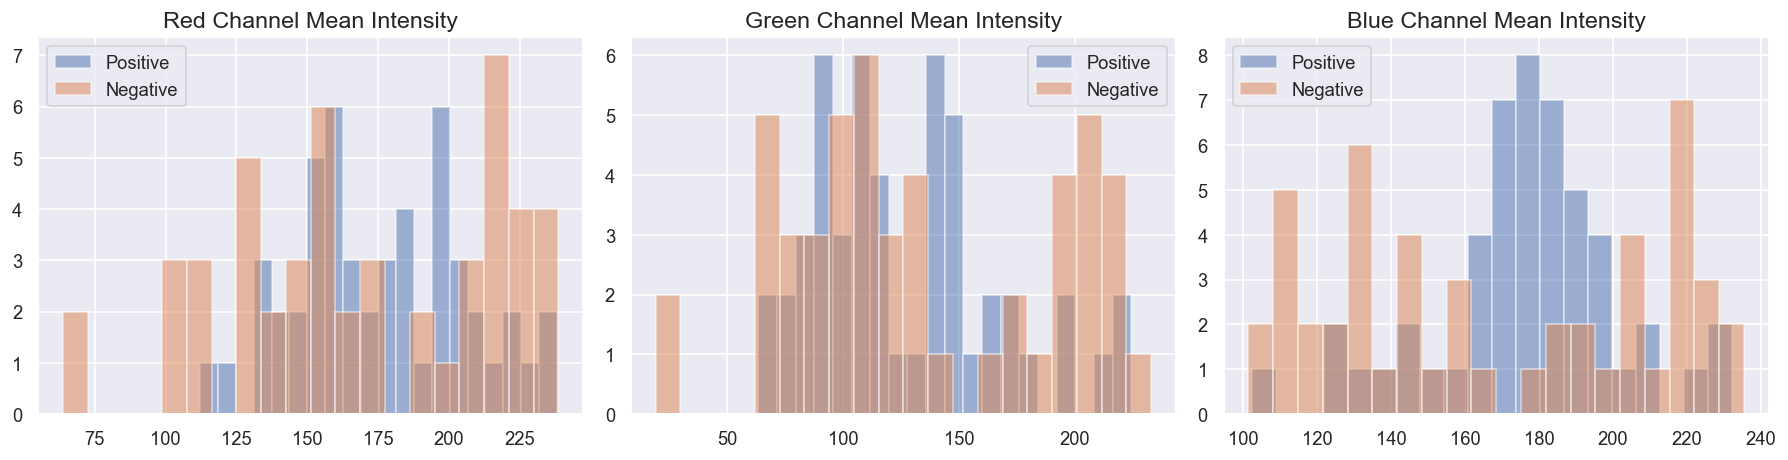

Figure saved: figs/5511_module3/intensity_distributionspng.png


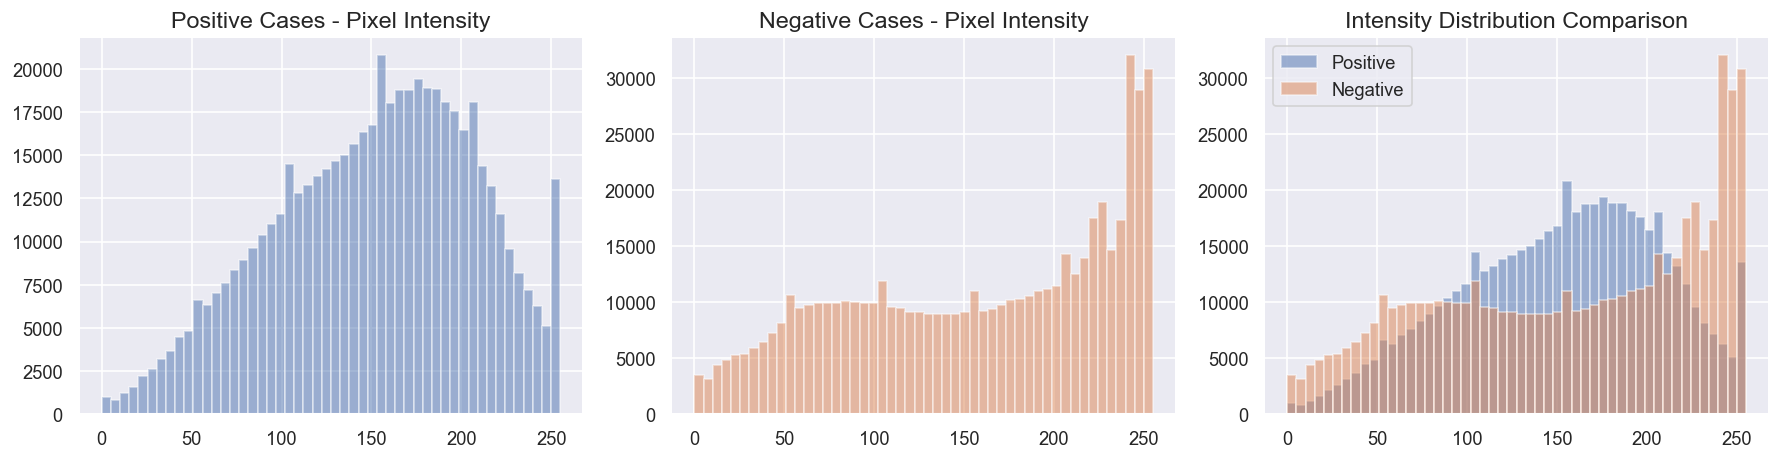

Figure saved: figs/5511_module3/texture_analysispng.png


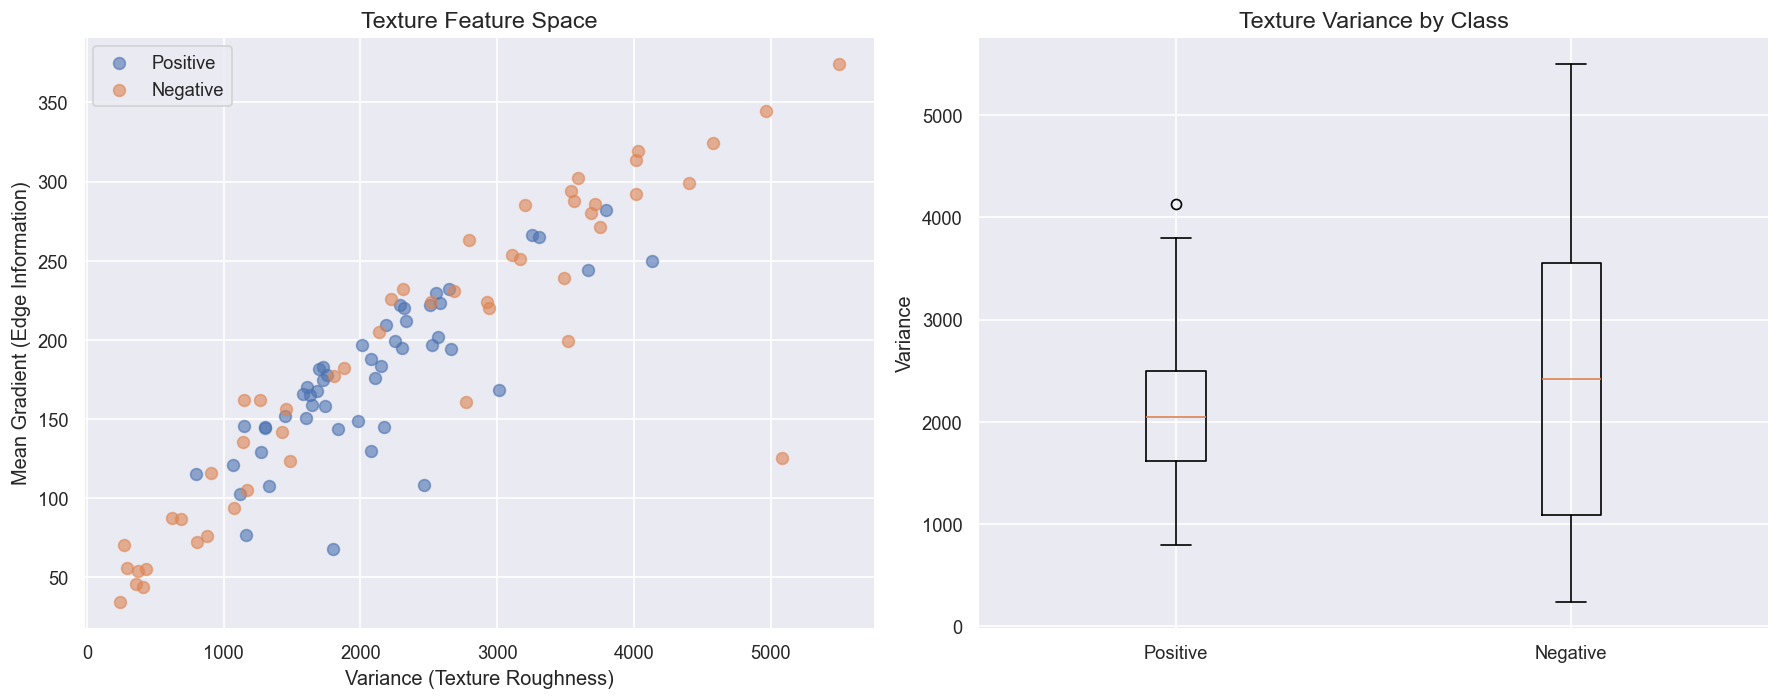

Figure saved: figs/5511_module3/Positive_samples_tifpng.png


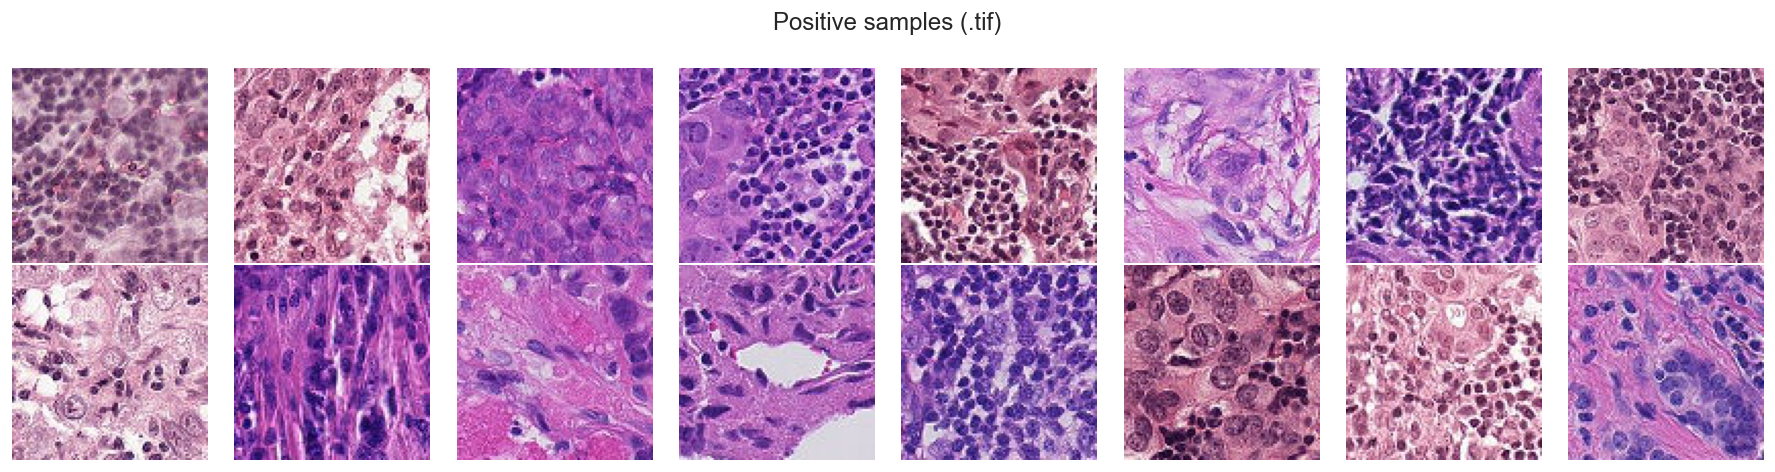

Figure saved: figs/5511_module3/Negative_samples_tifpng.png


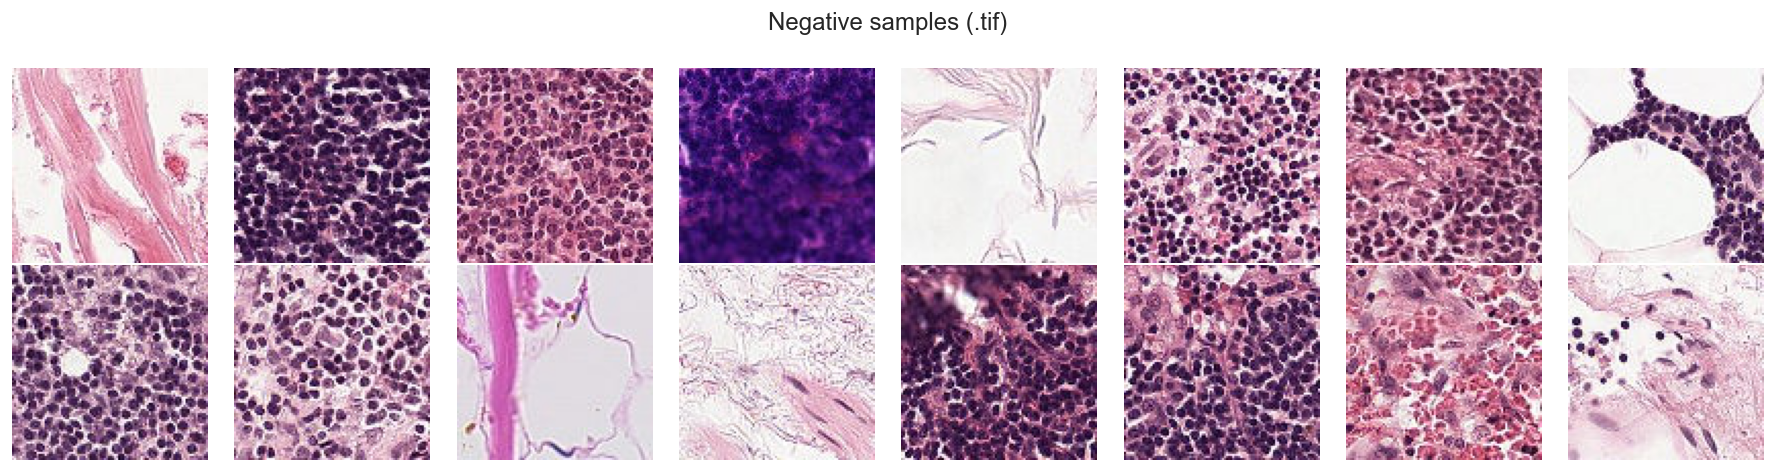

In [6]:
#Analyze intensity distribution
analyze_color_channels(pos_ids, neg_ids)
plot_intensity_distributions(pos_ids, neg_ids)
texture_analysis(pos_ids, neg_ids)
# Plot visual samples
pos_data = plot_tifs(pos_ids, "Positive samples (.tif)")
neg_data = plot_tifs(neg_ids, "Negative samples (.tif)")

Figure saved: figs/5511_module3/train_test_distributionspng.png


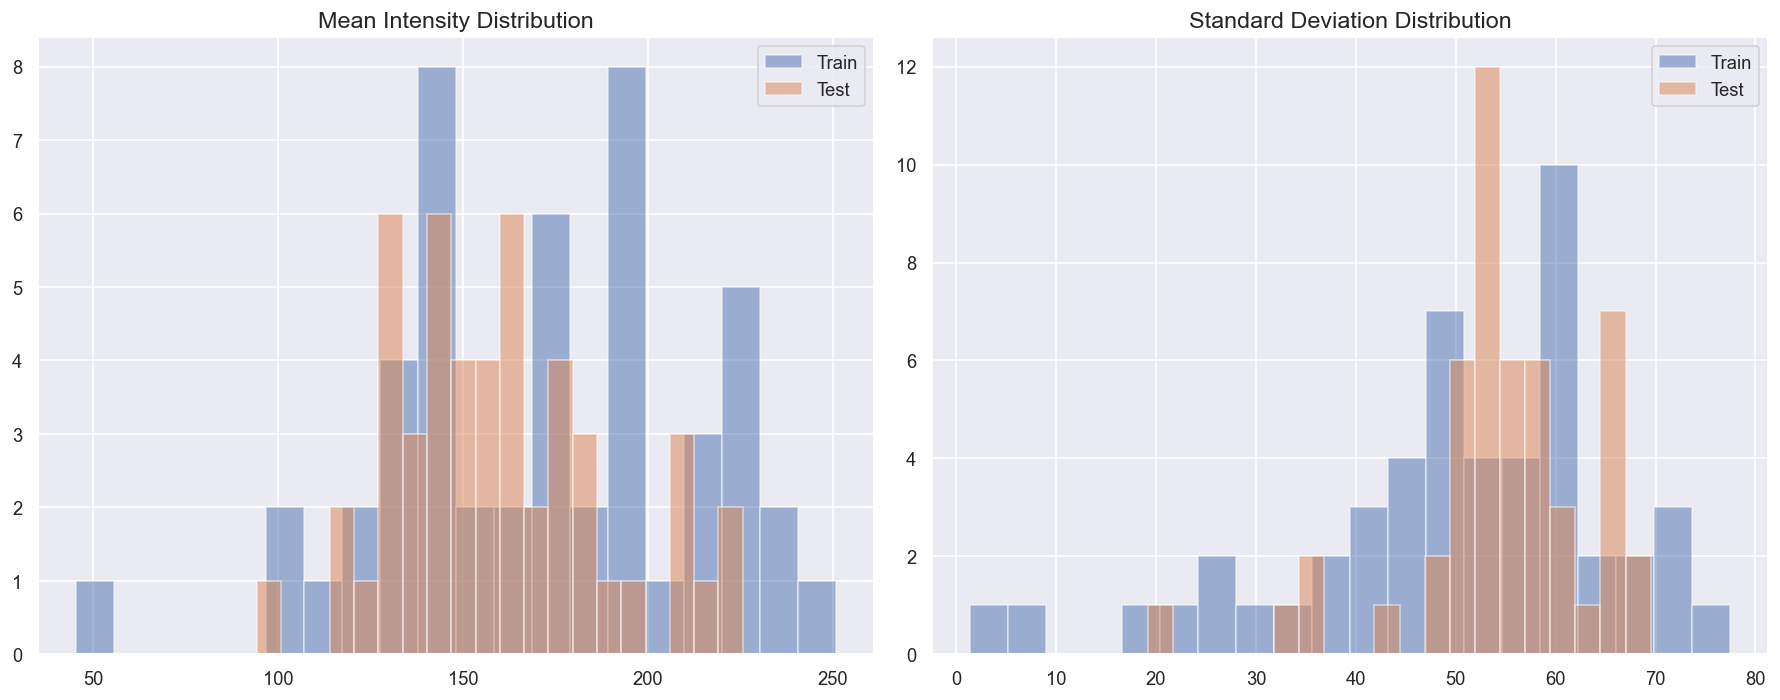

In [7]:
## Check similarity between train and test sets
compare_train_test_distributions(train_ids, test_ids)

### Observations from Initial EDA
1) We have n_samples = 220,025 in the training data
2) Classes are no too unbalanced (positive = 40.5%, negative 59.5%), I will probably anyway use stratified sampling, but it is good to know.
3) No issues with missing files or duplicates,(with same id, haven't checked actual images).
4) Images are in .tif format and seem to have a consistent shape (96,96,3) and dtype = uint8.
5) Images are small and standardised, no doubt to reduce the effort required in the competition setting. Nonetheless, in preprocessing, it may be worth checking (corrupted images, differing sizes, etc.)
5) The colour channel analysis shows that the blue channel may be most helpful in separating positive and negative cases. Positive cases have a tight distribution around blue mean intensity values between 160 and 200.
6) The intensity distributions show more pixels are high intensity (value > 230) for negative cases. Whereas, positive cases have a distribution closer to normal distribution in shape with a peak around intensity = 170
7) The texture analysis shows that positive cases have a wider distribution for variance (texture roughness) than negative cases. (more white areas, higher variation in intensity)
7) Looking at the grid of visual samples: positive cases are visibly bluer, and tend to have less white (high-intensity) area. The features are less distinct (less variation in intensity) than for the negative samples.
9) Happily, the test and train sets seem quite similar.

## Preprocessing

Needs to start by creating a clean tf.data.Dataset based on pre-split train/val sets.
1) Add 'file_paths' column to the train_labels df and split into file_paths and labels
3) scikit-learn train_test_split with stratify=labels
4) Base loader: decode/resize/scale only, note: the competition is asking for 32 x 32 crops from the 96 x 96 center
5) Had to create a function to load the TIFF image using tifffile and convert to tensor (tf doesn't natively support.tif)
5) Branch into train/val pipelines, shuffle train, no shuffle val (shuffle train avoids bias and stabilizes learning. Keep validation deterministic.)
6) Augmentation will be done later in the model training loop.

### Blue Channel Only

Based on the EDA results, it seems that the blue channel is the most helpful in separating positive and negative cases. Using a single channel (blue) could improve the model performance.
1) A Strong signal
2) Faster training due to reduced input size (96,96,1) three times smaller than (96,96,3). Note, h & w will be scaled to fit model, but depth will be reduced by a factor of 3.
3) Reduces the number of parameters in the model. (Less memory usage, faster training, reduced risk of overfitting.)

To confirm this hypothesis, I will need to compare the performance of a model with all channels and blue channel only. So preprocessing will need to deliver two datasets.

In [25]:
### Step 1 - create a clean tf.data.Dataset based on pre-split train/val sets

# 1) Split BEFORE building tf.data
## Add a filepaths column to the train_labels df
train_labels['file_paths'] = train_labels.id.apply(lambda x: str(TRAIN_DIR / f"{x}.tif"))
# split into file_paths and labels
file_paths = train_labels['file_paths']
labels = train_labels['label']
X_tr, X_val, y_tr, y_val = train_test_split(
    file_paths, labels, test_size=0.2, stratify=labels, random_state=SEED
)

## TARGET image size needs to be set according to model requirements
## Some pre-trained prefer 224,224. Sticking to 128,128 as a compromise (speed/performance) for now.
TARGET = (128, 128)
BATCH_SIZE = 256 # Tried it with 32, took ages, setting to higher number to cope with data set size.

# 2) Base loader: decode/resize/scale only
## note the parameter "channels" can take values "rgb" or "b" for now, to allow separation of blue channel
def load_base(path, label, channels = 'rgb', size=TARGET):
    """Load TIFF image using tifffile and convert to tensor"""
    # Use tf.py_function to call Python function from within TensorFlow graph
    def load_tiff_image(path):
        # Convert tensor to string
        path_str = path.numpy().decode('utf-8')
        # Load TIFF using tifffile
        img = tiff.imread(path_str)
        # Ensure it's float32 and normalized
        img = img.astype(np.float32) / 255.0
        if img.shape != (96, 96, 3):
            # Resize if needed to ensure consistent input shape
            img = resize(img, (96, 96, 3), anti_aliasing=True, preserve_range=True)
            #img = img.astype(np.float32)
        if channels == 'b':
            img = img[:, :, 2]
            img = np.expand_dims(img, axis=-1)
        return img
    # Use tf.py_function to wrap the Python function
    img = tf.py_function(
        func=load_tiff_image,
        inp=[path],
        Tout=tf.float32
    )
    # Set the shape explicitly (TensorFlow loses shape info with py_function)
    if channels == 'b':
        img.set_shape([96, 96, 1]) # blue channel only
    else:
        img.set_shape([96, 96, 3]) # rgb image

    # crop 32x32 from the 96x96 center - this is due to the competition requirement detailed above
    h, w = 96, 96
    y0 = (h - 32)//2; x0 = (w - 32)//2
    img = img[y0:y0+32, x0:x0+32, :]
    # upscale to model requirements
    img = tf.image.resize(img, size, method="bilinear")
    return img, label

def make_base_dataset(paths, labels, batch_size=BATCH_SIZE, channels='rgb'):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.cache()  # Cache the raw data before any processing
    ds = ds.map(
        lambda path, label: load_base(path, label, channels),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    return ds.batch(batch_size)

# 3) Branch into train/val pipelines and add step-specific transforms
def add_train_ops(ds, shuffle_size):
    ds = ds.shuffle(shuffle_size)
    #ds = ds.cache()
    #ds = ds.repeat() # to ensure full consumption across epochs
    return ds.prefetch(tf.data.AUTOTUNE)

def add_val_ops(ds):
    # No augmentation, no shuffle
    ds = ds.cache()
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = add_train_ops(make_base_dataset(X_tr, y_tr), shuffle_size=len(X_tr))
val_ds   = add_val_ops(make_base_dataset(X_val, y_val))

train_blue = add_train_ops(make_base_dataset(X_tr, y_tr, channels = 'b'), shuffle_size=len(X_tr))
val_blue   = add_val_ops(make_base_dataset(X_val, y_val, channels = 'b'))


In [26]:
# Check it worked - Have run this a few times and it works fine.
def dataset_name(dataset_var_name):
    """Get dataset name from variable name"""
    name_mapping = {
        'train_ds': 'Training Dataset (RGB)',
        'val_ds': 'Validation Dataset (RGB)',
        'train_blue': 'Training Dataset (Blue Channel)',
        'val_blue': 'Validation Dataset (Blue Channel)',
        'train_tiny': 'Training Dataset (Tiny)',
        'train_small': 'Training Dataset (Small)',
        'train_medium': 'Training Dataset (Medium)'
    }
    return name_mapping.get(dataset_var_name, 'Unknown Dataset')

def check_label_distribution(dataset, dataset_name):
    """Check class distribution in the dataset"""
    print(f"\n=== {dataset_name(dataset_name)} Label Distribution ===")

    all_labels = []
    for _, labels in dataset:
        all_labels.extend(labels.numpy().tolist())

    unique, counts = np.unique(all_labels, return_counts=True)
    total = len(all_labels)

    for label, count in zip(unique, counts):
        percentage = (count / total) * 100
        print(f"Label {label}: {count} samples ({percentage:.1f}%)")

    return dict(zip(unique, counts))

def check_with_iterator(dataset, name):
    """Check dataset with iterator"""
    print(f"\n=== Checking dataset with iterator for {dataset_name(name)} ===")
    iterator = dataset.as_numpy_iterator()
    images, labels = next(iterator)
    print(f"Batch shape: {images.shape}")
    print(f"Image range: [{images.min():.3f}, {images.max():.3f}]")
    print("Dataset creation successful!")
    print("-" * 60)

# Check label distribution
#train_dist = check_label_distribution(train_ds, "Training")
#val_dist = check_label_distribution(val_ds, "Validation")

# Check with iterator
check_with_iterator(train_ds, "train_ds")
check_with_iterator(train_blue, 'train_blue')


=== Checking dataset with iterator for Training Dataset (RGB) ===


2025-10-05 15:47:54.418902: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:290: Filling up shuffle buffer (this may take a while): 100 of 176020
2025-10-05 15:48:04.483761: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:290: Filling up shuffle buffer (this may take a while): 200 of 176020
2025-10-05 15:48:24.407115: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:290: Filling up shuffle buffer (this may take a while): 407 of 176020
2025-10-05 15:48:34.501210: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:290: Filling up shuffle buffer (this may take a while): 501 of 176020
2025-10-05 15:48:52.591356: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


Batch shape: (256, 128, 128, 3)
Image range: [0.000, 1.000]
Dataset creation successful!
------------------------------------------------------------

=== Checking dataset with iterator for Training Dataset (Blue Channel) ===


2025-10-05 15:49:03.548653: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:302: Filling up shuffle buffer (this may take a while): 123 of 176020
2025-10-05 15:49:23.526741: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:302: Filling up shuffle buffer (this may take a while): 365 of 176020
2025-10-05 15:49:43.581212: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:302: Filling up shuffle buffer (this may take a while): 600 of 176020
2025-10-05 15:49:52.777198: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


Batch shape: (256, 128, 128, 1)
Image range: [0.044, 1.000]
Dataset creation successful!
------------------------------------------------------------


In [27]:
# try it out
def test_model_compatibility(dataset, channels_type='rgb', name="Training Dataset"):
    """Test if dataset is compatible with a simple model"""
    start_time = time.time()
    print(f"\n=== Model Compatibility Test for{dataset_name(name)} ===")
    if channels_type == 'b':
        c = 1
    else:
        c = 3

    # Create a simple model to test compatibility
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(128, 128, c)),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    try:
        # Try to fit one batch
        for images, labels in dataset.take(1):
            loss = model.train_on_batch(images, labels)
            print(f"✓ Successfully processed one batch")
            print(f"  Loss: {loss[0]:.4f}, Accuracy: {loss[1]:.4f}")
            break
        print("✓ Dataset is compatible with model training!")
        success = True

    except Exception as e:
        print(f"✗ Error processing dataset: {e}")
        success = False

    end_time = time.time()
    execution_time = end_time - start_time
    print(f"⏱️ Execution time: {execution_time:.3f} seconds")

    return success, execution_time

# Test compatibility
_, rgb_time = test_model_compatibility(train_ds, channels_type='rgb',name='train_ds')
_, blue_time = test_model_compatibility(train_blue,channels_type='b',name='train_blue')


=== Model Compatibility Test forTraining Dataset (RGB) ===


2025-10-05 15:51:01.613429: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:290: Filling up shuffle buffer (this may take a while): 104 of 176020
2025-10-05 15:51:21.551205: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:290: Filling up shuffle buffer (this may take a while): 315 of 176020
2025-10-05 15:51:31.554803: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:290: Filling up shuffle buffer (this may take a while): 414 of 176020
2025-10-05 15:51:41.607878: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:290: Filling up shuffle buffer (this may take a while): 517 of 176020
2025-10-05 15:51:57.640841: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


✓ Successfully processed one batch
  Loss: 0.6811, Accuracy: 0.6211
✓ Dataset is compatible with model training!
⏱️ Execution time: 67.127 seconds

=== Model Compatibility Test forTraining Dataset (Blue Channel) ===


2025-10-05 15:52:08.731294: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:302: Filling up shuffle buffer (this may take a while): 125 of 176020
2025-10-05 15:52:28.737733: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:302: Filling up shuffle buffer (this may take a while): 376 of 176020
2025-10-05 15:52:48.710613: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:302: Filling up shuffle buffer (this may take a while): 619 of 176020
2025-10-05 15:52:54.480991: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


✓ Successfully processed one batch
  Loss: 0.6930, Accuracy: 0.4727
✓ Dataset is compatible with model training!
⏱️ Execution time: 56.609 seconds


### Preprocessing observations
That was painful, principally because I am new to Keras. I discovered and fixed:
- ImageDataGenerator is deprecated, which nearly all the examples I found online or on Kaggle have used
- There is no equivalent to load_from_dataframe, base expectation (one class per directory) is not satisfied either.)
- tf doesn't accept tiff files as input so needed a custom loader using tiffile
- fixing the shape of the images proved critical to avoid performance issues (loading tiff using a py_function wrapper is nasty)
- I experienced problems with strings becoming tensors in the tf pipeline, which needed to be converted back to strings for tiffile.
- Ended up creating (with a lot of help from AI and Google) the functions above to load train and val as tf.data.Datasets
- I had to shuffle the train set to avoid bias and stabilize learning. There still seems to be an issue with the sequence of this shuffle, the caching and subsequent operations (take(1)). Fixeed by commenting out the caching in add_train_ops, not convinced this is really the solution, may need to address later.

I note these issues, primarily for my learning and memory when I meet them next time.

### Blue version

Inconclusive, to complete the simple compatibility model for 1 batch:
- First execution: faster 58 secs vs 68 secs, lower accuracy: 0.53 vs 0.6
- Second execution: faster 58 secs vs 66 secs , higher accuracy: 0.53 vs 0.43
- The accuracy metric is too unstable to be usable with just one batch.

However, the speed advantage of the blue model is worth having whilst tuning the model architecture. I'm not sure the impact is linear, but 10 secs x 688 batches could be a time saving of allmost 2 hours of training time.

### Rookie Mistake
So having done the above, I tried a simple model which trained for 6 hours without completing epoch 7. I aborted the training and restarted. It looked like AUC was going to end up around 0.86 or so and loss below 0.4. But, obviously: I need to build some smaller sampled datasets to develop, tune and test the model.


In [28]:
def create_small_dataset(X_full, y_full, sample_size=1000, test_size=0.2):
    """Create a smaller, balanced dataset for quick experiments"""

    # First, sample a small subset while maintaining class balance
    X_sample, _, y_sample, _ = train_test_split(
        X_full, y_full,
        train_size=sample_size,
        stratify=y_full,
        random_state=42
    )

    # Then split into train/val
    X_train_small, X_val_small, y_train_small, y_val_small = train_test_split(
        X_sample, y_sample,
        test_size=test_size,
        stratify=y_sample,
        random_state=42
    )
    return X_train_small, X_val_small, y_train_small, y_val_small

# Define different dataset sizes for different stages
dataset_configs = {
    'tiny': 1000,      # Architecture testing
    'small': 5000,     # Hyperparameter tuning
    'medium': 20000,   # Final validation
    'full': len(X_tr)  # Final training
}

def create_dataset_by_size(size_name='small', channels='b'):
    sample_size = dataset_configs[size_name]

    if sample_size >= len(X_tr):
        # Use full dataset
        X_train, y_train, y_val = X_tr, y_tr #(validation X_val, y_val is unchanged)
    else:
        # Sample subset
        X_train, X_val, y_train, y_val = create_small_dataset(
            X_tr, y_tr, sample_size=sample_size
        )

    train_ds = add_train_ops(
        make_base_dataset(X_train, y_train, channels=channels),
        shuffle_size=len(X_train)
    )
    val_ds = add_val_ops(make_base_dataset(X_val, y_val, channels=channels))

    print(f"Created '{size_name}' dataset: {len(X_train)} training samples")
    return train_ds, val_ds

# Usage for different stages
train_tiny, val_tiny = create_dataset_by_size('tiny', channels='b')      # Quick architecture tests
train_small, val_small = create_dataset_by_size('small', channels='b')   # Hyperparameter tuning
train_medium, val_medium = create_dataset_by_size('medium', channels='b') # Pre-final validation

check_with_iterator(train_tiny, 'train_tiny')
check_with_iterator(train_small, 'train_small')
check_with_iterator(train_medium, 'train_medium')

Created 'tiny' dataset: 800 training samples
Created 'small' dataset: 4000 training samples
Created 'medium' dataset: 16000 training samples

=== Checking dataset with iterator for Training Dataset (Tiny) ===
Batch shape: (256, 128, 128, 1)
Image range: [0.052, 1.000]
Dataset creation successful!
------------------------------------------------------------

=== Checking dataset with iterator for Training Dataset (Small) ===
Batch shape: (256, 128, 128, 1)
Image range: [0.011, 1.000]
Dataset creation successful!
------------------------------------------------------------

=== Checking dataset with iterator for Training Dataset (Medium) ===
Batch shape: (256, 128, 128, 1)
Image range: [0.035, 1.000]
Dataset creation successful!
------------------------------------------------------------


## Model Development

### Model Architecture
_Describe your model architecture and reasoning for why you believe that specific architecture would be suitable for this problem._
My primary objective is learning, so I will keep it simple. I'm sure my model won't win any Kaggle competitions, but for now it is more important to me that I understand what I'm doing.

So I will use a Sequential model with the following layers:
- Input (blue or rgb shape)
- Conv2D (32, 3, activation='relu') * 3
- MaxPooling2D (2, 2)
- GlobalAveragePooling2D()
- Dense (128, activation='relu')
- Dense (64, activation='relu')
- Dense (1, activation='sigmoid')

### Model Tuning
The project asks us to compare models with different architectures and tune hyperparameters.
1) Compare the same model with rgb and blue channel only.
2) I will use one of the pre-trained models from the Keras library (VGG16) and add a few layers to it.

For hyperparameter tuning, I will focus on learning rate, but also try varying the number of epochs (see if it starts over-fitting.
- Learning rate: [0.01, 0.005, 0.001, 0.0005, 0.0001]
- Epochs: 10, 20, 30 - potentially, first I will use 20 and see what happens with a callback for early stopping.
- Loss: binary_crossentropy
- Optimizer: Adam

In [50]:
# Global Variables to handle the differing input shapes
BLUE_SHAPE = (128, 128, 1)
RGB_SHAPE = (128, 128, 3)

# Use a function to define the model, so that we can call it when running multiple experiments.
# For example, to try multiple learning rates

def create_model(shape=BLUE_SHAPE):
    """Create and return model architecture (without compilation)"""
    model = Sequential([
        Input(shape=shape),
        Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
        Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
        Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
        MaxPooling2D((2,2)),
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

# Check function works as expected
blue_model = create_model(BLUE_SHAPE)
blue_model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_12     │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,361 (122.50 KB)

 Trainable params: 31,361 (122.50 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
# Function to plot charts for Loss and AUC after each experiment
def plot_history(history, fig_filename='history plots'):
    epoch_range = range(1, len(history['loss'])+1)
    # Create DataFrame with all metrics
    df = pd.DataFrame({
        'Epoch': list(epoch_range) * 4,
        'Value': (history['loss'] + history['val_loss'] +
                 history['AUC'] + history['val_AUC']),
        'Metric': (['Loss'] * len(epoch_range) + ['Loss'] * len(epoch_range) +
                  ['AUC'] * len(epoch_range) + ['AUC'] * len(epoch_range)),
        'Dataset': (['Training'] * len(epoch_range) + ['Validation'] * len(epoch_range) +
                   ['Training'] * len(epoch_range) + ['Validation'] * len(epoch_range))
    })

    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Loss plot
    loss_data = df[df['Metric'] == 'Loss']
    sns.lineplot(data=loss_data, x='Epoch', y='Value', hue='Dataset',
                marker='o', ax=axes[0])
    axes[0].set_title('Loss')
    axes[0].set_ylabel('Loss')

    # AUC plot
    auc_data = df[df['Metric'] == 'AUC']
    sns.lineplot(data=auc_data, x='Epoch', y='Value', hue='Dataset',
                marker='o', ax=axes[1])
    axes[1].set_title('AUC')
    axes[1].set_ylabel('AUC')

    plt.tight_layout()
    save_figure(fig_filename)
    plt.show()
    return df

In [55]:
def train_with_learning_rates(model_func, train_ds, val_ds, learning_rates, epochs=10):
    """
    Train model with different learning rates and track best results

    Args:
        model_func: Function that returns a model (without optimizer)
        train_ds: Training dataset
        val_ds: Validation dataset
        learning_rates: List of learning rates to try
        epochs: Number of epochs per run

    Returns:
        DataFrame with results for each learning rate
    """
    results = []

    for lr in learning_rates:
        print(f"\n{'='*60}")
        print(f"Training with learning rate: {lr}")
        print(f"{'='*60}")

        # Create fresh model for each learning rate
        model = model_func()

        # Compile with current learning rate
        opt = tf.keras.optimizers.Adam(learning_rate=lr)
        model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['AUC'])

        # Train model
        history = model.fit(
            train_ds,
            epochs=epochs,
            validation_data=val_ds,
            callbacks=[early_stop],
            verbose=0
        )

        # Find best epoch (highest validation AUC)
        val_aucs = history.history['val_AUC']
        best_epoch = np.argmax(val_aucs) + 1  # +1 because epochs start at 1
        best_val_auc = max(val_aucs)
        best_train_auc = history.history['AUC'][best_epoch - 1]
        best_val_loss = history.history['val_loss'][best_epoch - 1]
        best_train_loss = history.history['loss'][best_epoch - 1]

        # Store results
        result = {
            'learning_rate': lr,
            'best_epoch': best_epoch,
            'best_val_auc': best_val_auc,
            'best_train_auc': best_train_auc,
            'best_val_loss': best_val_loss,
            'best_train_loss': best_train_loss,
            'final_val_auc': val_aucs[-1],  # Final epoch performance
            'history': history.history  # Store full history if needed
        }
        results.append(result)

        print(f"Best epoch: {best_epoch}, Best Val AUC: {best_val_auc:.4f}")
        plot_history(history.history,fig_filename=f"lr_{lr}")

    # Convert to DataFrame for easy analysis
    results_df = pd.DataFrame(results)
    return results_df


### Set hyperparameters and run experiments
Keep variable entry to next code cell.

In [59]:
# Set up variables for running experiments
train_size = 'small'

if train_size == 'tiny':
    print("Training with tiny dataset")
    train,val = train_tiny,val_tiny
elif train_size == 'small':
    print("Training with small dataset")
    train,val = train_small,val_small
elif train_size == 'medium':
    print("Training with medium dataset")
    train,val = train_medium,val_medium
else:
    print("Training on full dataset")
    train,val = train_blue, val_blue

# Set range of learning rates to try
learning_rates = [0.01, 0.005, 0.001, 0.0005, 0.0001]

# Set number of epochs to use
epochs = 20

# Define callbacks
early_stop = EarlyStopping(
    monitor='val_AUC',
    mode='max',
    patience=10,
    min_delta=1e-4,            # minimum change to qualify as improvement
    restore_best_weights=True, # roll back to best epoch
    verbose=1
)


Training with small dataset


In [ ]:
# Run experiments
results_df = train_with_learning_rates(
    model_func=create_model,
    train_ds=train,  # Use your dataset
    val_ds=val,
    learning_rates=learning_rates,
    epochs=epochs
)
# Display results sorted by best validation AUC
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
display(results_df[['learning_rate', 'best_epoch', 'best_val_auc', 'best_train_auc', 'best_val_loss']].sort_values('best_val_auc', ascending=False))

# Find overall best learning rate
best_lr_row = results_df.loc[results_df['best_val_auc'].idxmax()]
print(f"\nBest Learning Rate: {best_lr_row['learning_rate']}")
print(f"Best Validation AUC: {best_lr_row['best_val_auc']:.4f}")
print(f"Achieved at Epoch: {best_lr_row['best_epoch']}")


Training with learning rate: 0.01


In [ ]:
def plot_lr_comparison(results_df):
    """Plot comparison of learning rates"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Best validation AUC by learning rate
    sns.barplot(data=results_df, x='learning_rate', y='best_val_auc', ax=axes[0,0])
    axes[0,0].set_title('Best Validation AUC by Learning Rate')
    axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=45)

    # Best epoch by learning rate
    sns.barplot(data=results_df, x='learning_rate', y='best_epoch', ax=axes[0,1])
    axes[0,1].set_title('Best Epoch by Learning Rate')
    axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=45)

    # Training vs Validation AUC
    melted = results_df.melt(
        id_vars=['learning_rate'],
        value_vars=['best_train_auc', 'best_val_auc'],
        var_name='dataset', value_name='auc'
    )
    sns.barplot(data=melted, x='learning_rate', y='auc', hue='dataset', ax=axes[1,0])
    axes[1,0].set_title('Train vs Validation AUC')
    axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=45)

    # Learning rate vs final loss
    sns.scatterplot(data=results_df, x='learning_rate', y='best_val_loss',
                   size='best_val_auc', ax=axes[1,1])
    axes[1,1].set_title('Validation Loss vs Learning Rate')
    axes[1,1].set_xscale('log')

    plt.tight_layout()
    save_figure('learning_rate_comparison')
    plt.show()

# Plot the comparison
plot_lr_comparison(results_df)

## Results and Analysis
Run hyperparameter tuning, try different architectures for comparison, apply techniques to improve training or performance, and discuss what helped.

Includes results with tables and figures. There is an analysis of why or why not something worked well, troubleshooting, and a hyperparameter optimization procedure summary.

### Generating Competition Submission


## Conclusion
Discuss and interpret results as well as learnings and takeaways. What did and did not help improve the performance of your models? What improvements could you try in the future?

## Citations

Thatha, V.N., Karthik, M.G., Gaddam, V.G. et al. Histopathological image based breast cancer diagnosis using deep learning and bio inspired optimization. Sci Rep 15, 19034 (2025). https://rdcu.be/eJqBt

Histopathologic Cancer Detection with Hybrid Deep Learning model: https://dl.acm.org/doi/10.1145/3644116.3644199

Cancer diagnosis in histopathological image: CNN based approach: https://www.sciencedirect.com/science/article/pii/S2352914819301133


In [ ]:
from tensorflow import keras
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
])

inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs, training=True)  # active only during training
# ... rest of your model


Class imbalance handling
Stratified sampling was used during train-validation-test splits to maintain class ratios within each subset.

Weighted loss functions were applied during training to penalize misclassification of underrepresented classes more heavily, thus encouraging balanced learning.

Data augmentation techniques
To increase the effective sample size and introduce variability, we used the following augmentation techniques:

Rotation: ±15° random rotations.

Horizontal and vertical flipping.

Random zoom: ±10%.

Width and height shift: up to 10%.

Brightness and contrast adjustment.

These augmentations were applied dynamically during training using Keras’ ImageDataGenerator and PyTorch transforms, depending on the framework used.

Proposed system model
The process of feeding information into the suggested model, AlexNet-GRU, occurs after the preprocessing and feature extraction stages. The proposed framework for the classification of breast cancer involves the following steps:

Preprocessing: Histopathological images are preprocessed using convolution filters to enhance denoising and improve image quality.

Feature Extraction: DenseNet-41, a powerful convolutional neural network, is used to extract robust features capturing intricate patterns in the histopathological images.

Classification: The extracted features are fed into a hybrid model, AlexNet-GRU, which integrates the strengths of AlexNet for feature extraction and GRU for sequential data processing.

Optimization: The hyperparameters of the AlexNet-GRU model are fine-tuned using the Hippopotamus Optimization Algorithm (HOA). HOA is inspired by the social and defensive behaviors of hippopotamuses. It involves updating positions based on exploration and exploitation phases, where the positions represent potential solutions. This algorithm ensures efficient search for optimal hyperparameters, enhancing the model’s performance.

Evaluation: The performance of the model is evaluated using standard metrics such as accuracy, precision, recall, and F1-score.

